# Подготовка территорий

Используем класс `LandDataPreparator`, чтобы собрать единый набор данных и сохранить результат.

### Входные данные

**scenario_blocks_path = "../data/prostor/scenario_blocks.pickle"** — GeoDataFrame сценарных участков. Обязательные атрибуты: геометрия `geometry` (проекция в метрах), доли типов использования (`residential`, `business`, `recreation`, `industrial`, `transport`, `special`, `agriculture`), агрегированные показатели `land_use`, `share`, `footprint_area`, `build_floor_area`, `living_area`, `non_living_area`.

**context_blocks_path = "../data/prostor/context_blocks.pickle"** — GeoDataFrame контекстных участков с идентичной структурой и той же CRS; используется для объединения с сценарными блоками.



In [1]:
import pandas as pd

scenario_blocks = pd.read_pickle('../data/scenario_blocks.pickle') #or baseline_blocks
context_blocks = pd.read_pickle('../data/context_blocks.pickle')


In [2]:
scenario_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN


In [3]:
context_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,capacity_supermarket,count_supermarket,capacity_swimming_pool,count_swimming_pool,capacity_train_station,count_train_station,capacity_university,count_university,capacity_veterinary,count_veterinary
0,"POLYGON ((391549.648 6642620.924, 391440.516 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,5000,1,1000,1,0,0,0,0,0,0
1,"POLYGON ((390728.805 6642824.074, 390766.253 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
2,"POLYGON ((384619.942 6643780.507, 384592.897 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
3,"POLYGON ((383701.245 6643709.235, 384459.417 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0
4,"POLYGON ((394792.785 6641449.688, 394618.737 6...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,NaN,...,0,0,0,0,0,0,0,0,0,0


In [4]:
from urbanomy.methods.land_value_modeling.land_data_preparation import LandDataPreparator

preparator = LandDataPreparator(
    scenario_blocks_source=scenario_blocks,
    context_blocks_source=context_blocks,
    predict_project_only=False, 
)

prepared_blocks = preparator.prepare()
prepared_blocks.head()

2025-12-16 12:02:06.069 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,share,footprint_area,build_floor_area,...,fsi,gsi,mxi,l,area_accessibility,land_use,morphotype,is_project,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,0.918180,6260.339339,12550.410318,...,0.062008,0.030931,0.000000,2.004749,127.337432,LandUse.AGRICULTURE,low-rise non-residential,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,0.938081,18143.803825,40777.536145,...,0.202340,0.090031,0.000000,2.247463,125.993903,LandUse.BUSINESS,low-rise non-residential,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,0.891381,15011.639457,24985.649917,...,0.151737,0.091165,0.000000,1.664418,123.419051,LandUse.TRANSPORT,low-rise non-residential,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,0.934862,22467.050757,72568.692640,...,0.449142,0.139053,0.404539,3.230005,122.524407,LandUse.RESIDENTIAL,low-rise model,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,NaN,0.316008,1.306345,...,0.079224,0.019165,0.000000,4.133894,122.658674,None,mid-rise non-residential,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


In [5]:
prepared_blocks.columns.tolist()

['residential',
 'business',
 'recreation',
 'industrial',
 'transport',
 'special',
 'agriculture',
 'share',
 'footprint_area',
 'build_floor_area',
 'living_area',
 'non_living_area',
 'population',
 'site_area',
 'fsi',
 'gsi',
 'mxi',
 'l',
 'area_accessibility',
 'land_use',
 'morphotype',
 'is_project',
 'geometry',
 'id']

<Axes: >

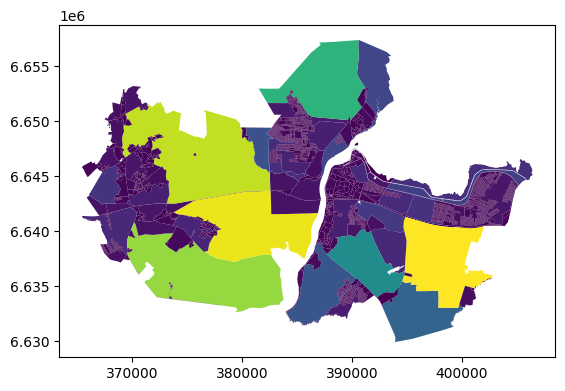

In [5]:
prepared_blocks.plot(column='footprint_area')

In [ ]:
prepared_blocks.to_pickle("../data/scenario_prepared_blocks.pickle") #or baseline_prepared_blocks.pickle
